In [1]:
import torch
import numpy as np
import os
import torch.nn as nn

In [2]:
data_dir = "../data/tiny-imagenet-200"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")

# torch.manual_seed(42)

In [3]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(0.5, 0.5)
])
train_dataset = ImageFolder(train_dir, transform = train_transforms)

In [4]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
images, labels = next(iter(train_loader))
import torchvision
grid = torchvision.utils.make_grid(images, nrow=4)

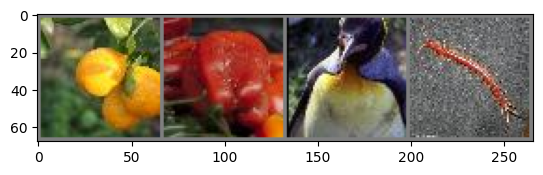

In [5]:
import matplotlib.pyplot as plt
plt.imshow(grid.permute(1, 2, 0).cpu() * 0.5 + 0.5)

In [6]:
print("Range : [", grid.min().item(), ",", grid.max().item(), "]" )
print(" image shape :", images[0].shape)

Range : [ -1.0 , 1.0 ]
 image shape : torch.Size([3, 64, 64])


In [ ]:
class VGGNet(nn.Module):

    def __init__(self):
        super().__init__()
        in_channels = 3
        self.conv1 = nn.ModuleList([
            nn.Conv2d(in_channels, 64, 3, padding="same"),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding ="same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ])
        self.conv2 = nn.ModuleList([
            nn.Conv2d(64, 128, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding = "same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ])
        self.conv3 = nn.ModuleList([
            nn.Conv2d(128, 256, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding = "same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ])
        self.conv4 = nn.ModuleList([
            nn.Conv2d(256, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ])

        self.conv5 = nn.ModuleList([
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding = "same"),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        ])
        self.flatten = nn.Flatten()
        self.linears = nn.ModuleList([
            nn.Linear(2048, 4096),
            nn.ReLU(),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Linear(4096, 200)
        ])

    def forward(self, x):
        for layer in self.conv1:
            x = layer(x)
        for layer in self.conv2:
            x = layer(x)
        for layer in self.conv3:
            x = layer(x)
        for layer in self.conv4:
            x = layer(x)
        for layer in self.conv5:
            x = layer(x)
        x = self.flatten(x)

        for linear in self.linears:
            x = linear(x)
        return x
vgg = VGGNet()
output = vgg(images)

In [68]:
torch.norm(output[0] - output[1]) > 1e-4

tensor(True)

In [62]:
assert not torch.allclose(output[0], output[1], rtol=1e-4), "output[0] and output[1] are the same!"

In [ ]:
import torch.nn.functional as F
class CustomCrossEntropyLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, output, target):
        N, C = output.shape
        assert (target < C).all(), "label target out of shape!"
        one_hot_labels = F.one_hot(target, num_classes=C)
        assert one_hot_labels.shape == output.shape, "one hot shape is not the same as output!"
        softmaxed_outputs = F.softmax(output, dim = 1)
        loss_value = torch.sum(-one_hot_labels * torch.log(softmaxed_outputs)) / N
        return loss_value

In [9]:
import torch.optim as optim
optimizer = optim.AdamW(vgg.parameters(), lr = 1e-3)
loss = CustomCrossEntropyLoss()
custom_loss = loss(output, labels)
ce_loss = nn.CrossEntropyLoss()
actual_loss = ce_loss(output, labels)
assert torch.isclose(actual_loss, custom_loss)

In [10]:
def train_model(model,criterion,optimizer,trainloader,num_iter,device):
    model = model.to(device)
    model.train() # Set the model to training mode
    cost = []
    for epoch in range(num_iter):

        running_loss = 0.0

        for i, data in enumerate(trainloader):

            # Get the inputs X and labels y for the minibatch
            inputs, labels = data[0].to(device), data[1].to(device)

            # Zero the gradients of the weights each iteration
            optimizer.zero_grad()

            # Calculate the predictions and the cost/loss
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Use autograd to calculate the gradient of the cost with respect to each weight
            loss.backward()

            # Use the optimizer to do the weights update
            optimizer.step()

            # Add the loss to running loss for the epoch
            running_loss += loss.item()

        cost.append(running_loss)
    return cost

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# cost = train_model(vgg, loss, optimizer, train_loader, 2, device)

In [12]:
# cost = [132913.0864663124, 132518.48417901993]

In [14]:
# np.savetxt("test.txt", cost)

In [15]:
model_dir = 'models/'
os.makedirs(os.path.dirname(model_dir), exist_ok=True)
filename = 'fullmodel.pt'

# Save the entire model
torch.save(vgg, model_dir+filename)

In [17]:
image, labels = next(iter(train_loader))

vgg(image)

tensor([[ 0.0029,  0.0113,  0.0026, -0.0163,  0.0114, -0.0047,  0.0219,  0.0163,
          0.0066,  0.0097,  0.0094, -0.0045,  0.0004,  0.0012, -0.0094, -0.0037,
          0.0159, -0.0160,  0.0100, -0.0083, -0.0155,  0.0154,  0.0101, -0.0120,
          0.0071,  0.0124,  0.0068, -0.0042,  0.0005,  0.0046,  0.0038, -0.0031,
          0.0062, -0.0087,  0.0027,  0.0147, -0.0021, -0.0123, -0.0156,  0.0066,
          0.0163,  0.0077, -0.0065,  0.0009,  0.0066,  0.0105, -0.0088, -0.0160,
          0.0002, -0.0088, -0.0138,  0.0093, -0.0118,  0.0083, -0.0104,  0.0084,
         -0.0032, -0.0049,  0.0125, -0.0105, -0.0198, -0.0124, -0.0067,  0.0111,
          0.0173, -0.0051,  0.0073,  0.0101,  0.0068, -0.0075, -0.0010,  0.0085,
         -0.0056,  0.0037,  0.0079,  0.0145, -0.0163, -0.0059,  0.0200, -0.0048,
         -0.0143, -0.0067,  0.0045,  0.0093, -0.0092, -0.0137,  0.0008,  0.0097,
          0.0062,  0.0182,  0.0034,  0.0150, -0.0086, -0.0080,  0.0110,  0.0002,
         -0.0065, -0.0097, -

In [18]:
image.shape

torch.Size([4, 3, 64, 64])

In [19]:
output = vgg(image)

In [20]:
output[0]

tensor([ 0.0029,  0.0113,  0.0026, -0.0163,  0.0114, -0.0047,  0.0219,  0.0163,
         0.0066,  0.0097,  0.0094, -0.0045,  0.0004,  0.0012, -0.0094, -0.0037,
         0.0159, -0.0160,  0.0100, -0.0083, -0.0155,  0.0154,  0.0101, -0.0120,
         0.0071,  0.0124,  0.0068, -0.0042,  0.0005,  0.0046,  0.0038, -0.0031,
         0.0062, -0.0087,  0.0027,  0.0147, -0.0021, -0.0123, -0.0156,  0.0066,
         0.0163,  0.0077, -0.0065,  0.0009,  0.0066,  0.0105, -0.0088, -0.0160,
         0.0002, -0.0088, -0.0138,  0.0093, -0.0118,  0.0083, -0.0104,  0.0084,
        -0.0032, -0.0049,  0.0125, -0.0105, -0.0198, -0.0124, -0.0067,  0.0111,
         0.0173, -0.0051,  0.0073,  0.0101,  0.0068, -0.0075, -0.0010,  0.0085,
        -0.0056,  0.0037,  0.0079,  0.0145, -0.0163, -0.0059,  0.0200, -0.0048,
        -0.0143, -0.0067,  0.0045,  0.0093, -0.0092, -0.0137,  0.0008,  0.0097,
         0.0062,  0.0182,  0.0034,  0.0150, -0.0086, -0.0080,  0.0110,  0.0002,
        -0.0065, -0.0097, -0.0158, -0.00

In [21]:
output[1]

tensor([ 0.0029,  0.0113,  0.0026, -0.0163,  0.0114, -0.0047,  0.0219,  0.0163,
         0.0066,  0.0097,  0.0094, -0.0045,  0.0004,  0.0012, -0.0094, -0.0037,
         0.0159, -0.0160,  0.0100, -0.0083, -0.0155,  0.0154,  0.0101, -0.0120,
         0.0071,  0.0124,  0.0068, -0.0042,  0.0005,  0.0046,  0.0038, -0.0031,
         0.0062, -0.0087,  0.0027,  0.0147, -0.0021, -0.0123, -0.0156,  0.0066,
         0.0163,  0.0077, -0.0065,  0.0009,  0.0066,  0.0105, -0.0088, -0.0160,
         0.0002, -0.0088, -0.0138,  0.0093, -0.0118,  0.0083, -0.0104,  0.0084,
        -0.0032, -0.0049,  0.0125, -0.0105, -0.0198, -0.0124, -0.0067,  0.0111,
         0.0173, -0.0051,  0.0073,  0.0101,  0.0068, -0.0075, -0.0010,  0.0085,
        -0.0056,  0.0037,  0.0079,  0.0145, -0.0163, -0.0059,  0.0200, -0.0048,
        -0.0143, -0.0067,  0.0045,  0.0093, -0.0092, -0.0137,  0.0008,  0.0097,
         0.0062,  0.0182,  0.0034,  0.0150, -0.0086, -0.0080,  0.0110,  0.0002,
        -0.0065, -0.0097, -0.0158, -0.00